# EDA: IBM Transactions for Anti Money Laundering (AML)

Датасет — синтетические банковские транзакции, сгенерированные IBM для задачи детекции отмывания денег.
Доступно несколько версий разного размера: `HI-Small`, `HI-Medium`, `HI-Large`, `LI-Small`, `LI-Medium`, `LI-Large`
(HI = *Higher Illicit ratio*, LI = *Lower Illicit ratio*; Small/Medium/Large — объём данных).

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

import warnings
warnings.filterwarnings("ignore")

## Загрузка данных

In [10]:
PATH = "../data/raw/LI-Small_Trans.csv"

DTYPES = {
    'From Bank': 'category',
    'Account': 'string',
    'To Bank': 'category',
    'Account.1': 'string',
    'Amount Received': 'float64',
    'Receiving Currency': 'category',
    'Amount Paid': 'float64',
    'Payment Currency': 'category',
    'Payment Format': 'category',
    'Is Laundering': 'bool',
}

In [11]:
def load_data(path, dtypes) -> pd.DataFrame:
    print(f"--> Чтение {path}")
    df = pd.read_csv(PATH, dtype=dtypes, parse_dates=['Timestamp'])

    df['Hour'] = df['Timestamp'].dt.hour
    df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
    df['Day'] = df['Timestamp'].dt.date
    df['Month'] = df['Timestamp'].dt.to_period('M')

    return df

df = load_data(PATH, DTYPES)
print(f"Память, занимаемая датафреймом: {df.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")
df.head()

--> Чтение ../data/raw/LI-Small_Trans.csv
Память, занимаемая датафреймом: 1,365.2 MB


,Timestamp,From Bank,Account,To Bank,Account.1,Amount Received,Receiving Currency,Amount Paid,Payment Currency,Payment Format,Is Laundering,Hour,DayOfWeek,Day,Month
0,2022-09-01 00:08:00,011,8000ECA90,011,8000ECA90,3195403.00,US Dollar,3195403.00,US Dollar,Reinvestment,False,0,3,2022-09-01,2022-09
1,2022-09-01 00:21:00,03402,80021DAD0,03402,80021DAD0,1858.96,US Dollar,1858.96,US Dollar,Reinvestment,False,0,3,2022-09-01,2022-09
2,2022-09-01 00:00:00,011,8000ECA90,001120,8006AA910,592571.00,US Dollar,592571.00,US Dollar,Cheque,False,0,3,2022-09-01,2022-09
3,2022-09-01 00:16:00,03814,8006AD080,03814,8006AD080,12.32,US Dollar,12.32,US Dollar,Reinvestment,False,0,3,2022-09-01,2022-09
4,2022-09-01 00:00:00,020,8006AD530,020,8006AD530,2941.56,US Dollar,2941.56,US Dollar,Reinvestment,False,0,3,2022-09-01,2022-09


In [12]:
df.describe()

,Timestamp,Amount Received,Amount Paid,Hour,DayOfWeek
count,6924049,6.924049e+06,6.924049e+06,6.924049e+06,6.924049e+06
mean,2022-09-05 07:09:11.289011456,6.324067e+06,4.676036e+06,1.050052e+01,2.993371e+00
min,2022-09-01 00:00:00,1.000000e-06,1.000000e-06,0.000000e+00,0.000000e+00
25%,2022-09-02 04:26:00,1.742100e+02,1.753800e+02,4.000000e+00,2.000000e+00
50%,2022-09-05 12:12:00,1.397620e+03,1.399440e+03,1.000000e+01,3.000000e+00
75%,2022-09-08 03:04:00,1.229633e+04,1.222687e+04,1.700000e+01,4.000000e+00
max,2022-09-17 15:28:00,3.644854e+12,3.644854e+12,2.300000e+01,6.000000e+00
std,NaN,2.105371e+09,1.544099e+09,7.370397e+00,1.516858e+00


## Целостность данных

In [18]:
print(f"Всего строк: {len(df)}")
print(f"Всего колонок: {df.shape[1]}")
print(f"Диапазон дат: {df.Timestamp.min()} - {df.Timestamp.max()}")
print()
df.info(memory_usage="deep")

Всего строк: 6924049
Всего колонок: 15
Диапазон дат: 2022-09-01 00:00:00 - 2022-09-17 15:28:00

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 15 columns):
 #   Column              Dtype         
---  ------              -----         
 0   Timestamp           datetime64[ns]
 1   From Bank           category      
 2   Account             string        
 3   To Bank             category      
 4   Account.1           string        
 5   Amount Received     float64       
 6   Receiving Currency  category      
 7   Amount Paid         float64       
 8   Payment Currency    category      
 9   Payment Format      category      
 10  Is Laundering       bool          
 11  Hour                int32         
 12  DayOfWeek           int32         
 13  Day                 object        
 14  Month               period[M]     
dtypes: bool(1), category(5), datetime64[ns](1), float64(2), int32(2), object(1), period[M](1), string(2)
memor

In [20]:
print("Пропусков:")
df.isna().sum()

Пропусков:


Timestamp             0
From Bank             0
Account               0
To Bank               0
Account.1             0
Amount Received       0
Receiving Currency    0
Amount Paid           0
Payment Currency      0
Payment Format        0
Is Laundering         0
Hour                  0
DayOfWeek             0
Day                   0
Month                 0
dtype: int64

In [21]:
full_dupes = df.duplicated().sum()
print(f"Полных дубликатов строк: {full_dupes} ({full_dupes / len(df):.4%})")

key_cols = ['Timestamp', 'Account', 'Account.1', 'Amount Paid', 'Amount Received']
dup_transactions = df.duplicated(subset=key_cols).sum()
print(f"Дубликатов по ключевым полям транзакции: {dup_transactions:,} ({dup_transactions / len(df):.4%})")


Полных дубликатов строк: 8 (0.0001%)
Дубликатов по ключевым полям транзакции: 14 (0.0002%)


## Дисбаланс

In [37]:
target_counts = df["Is Laundering"].value_counts()
target_pct = df["Is Laundering"].value_counts(normalize = True) * 100

print("Распределение классов")
for i in target_counts.index:
    label = 'Отмывание (1)' if i == 1 else 'Легитимные (0)'
    print(f"  {label}: {target_counts[i]} ({target_pct[i]:.4f}%)")

print()
imbalance_ratio = target_counts[0] / target_counts[1] 
print(f"Соотношение классов: {int(imbalance_ratio)} : 1")

Распределение классов
  Легитимные (0): 6920484 (99.9485%)
  Отмывание (1): 3565 (0.0515%)

Соотношение классов: 1941 : 1


## Паттерны

### Время

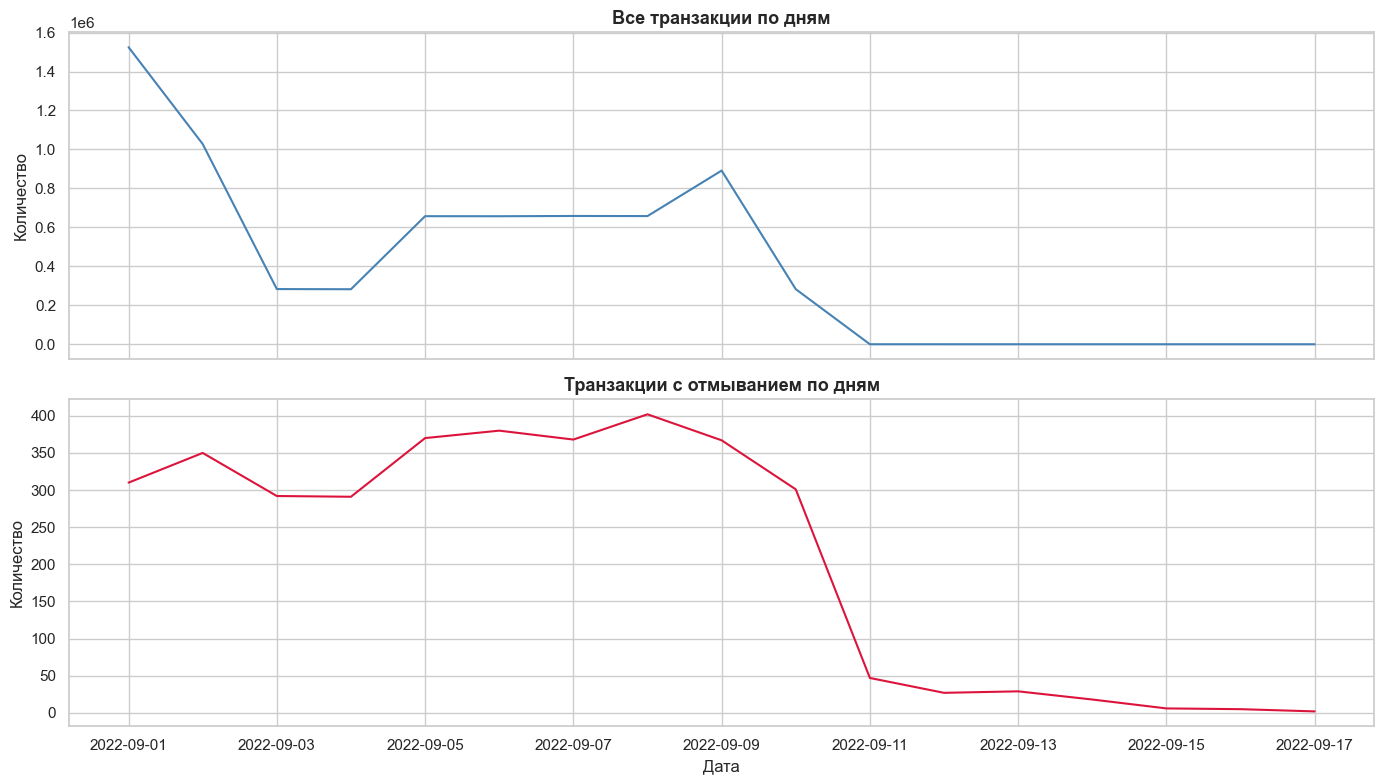

In [44]:
daily = df.groupby('Day').size()
daily_fraud = df[df['Is Laundering'] == 1].groupby('Day').size()

fig, ax = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
daily.plot(ax=ax[0], color='steelblue')
ax[0].set_title("Все транзакции по дням")
ax[0].set_ylabel("Количество")

daily_fraud.plot(ax=ax[1], color='crimson')
ax[1].set_title("Транзакции с отмыванием по дням")
ax[1].set_ylabel("Количество")
ax[1].set_xlabel("Дата")

plt.tight_layout()
plt.show()

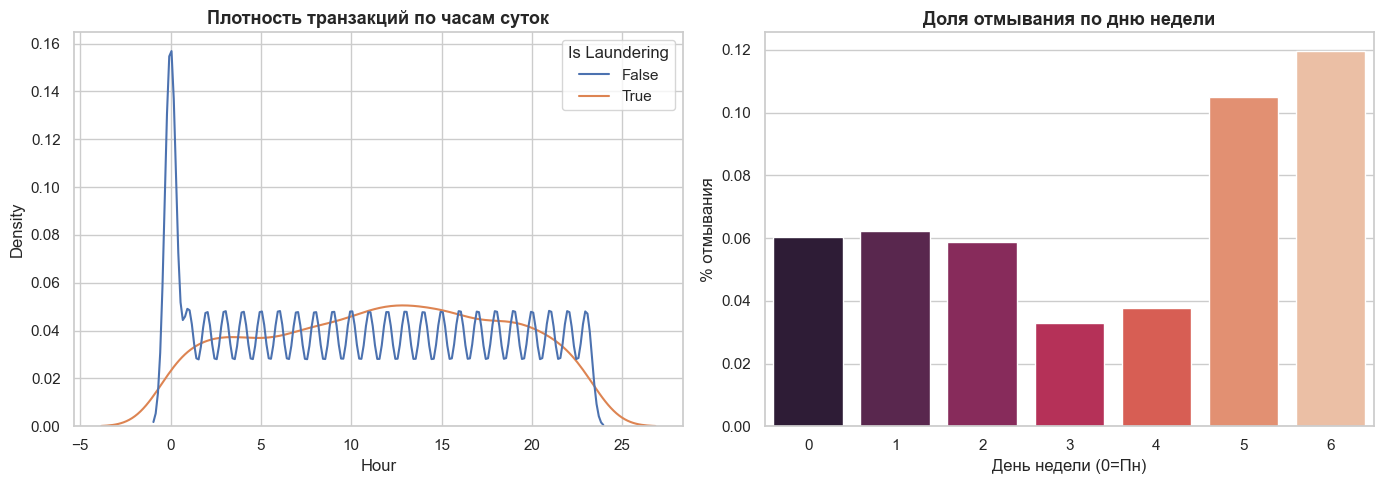

In [45]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.kdeplot(data=df, x='Hour', hue='Is Laundering', common_norm=False, ax=ax[0])
ax[0].set_title("Плотность транзакций по часам суток")

fraud_rate_by_dow = df.groupby('DayOfWeek')['Is Laundering'].mean() * 100
sns.barplot(x=fraud_rate_by_dow.index, y=fraud_rate_by_dow.values, ax=ax[1], palette="rocket")
ax[1].set_title("Доля отмывания по дню недели")
ax[1].set_xlabel("День недели (0=Пн)")
ax[1].set_ylabel("% отмывания")

plt.tight_layout()
plt.show()

### Суммы

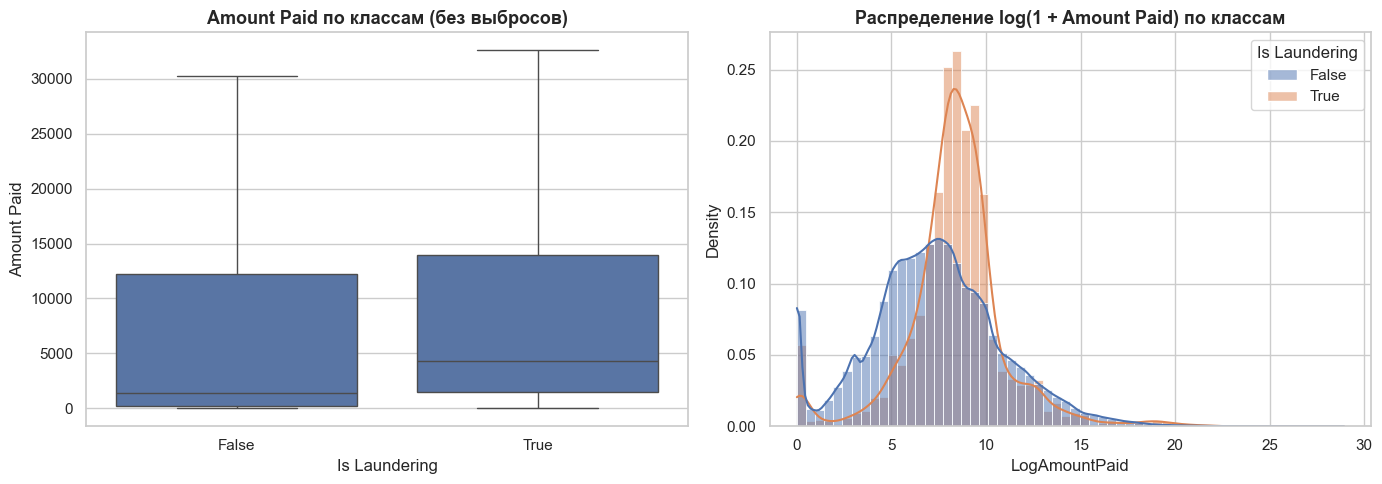

In [46]:
df['LogAmountPaid'] = np.log1p(df['Amount Paid'])

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Is Laundering', y='Amount Paid', ax=ax[0], showfliers=False)
ax[0].set_title("Amount Paid по классам (без выбросов)")

sns.histplot(data=df, x='LogAmountPaid', hue='Is Laundering', stat='density',
             common_norm=False, kde=True, ax=ax[1], bins=60)
ax[1].set_title("Распределение log(1 + Amount Paid) по классам")

plt.tight_layout()
plt.show()

### Валюта

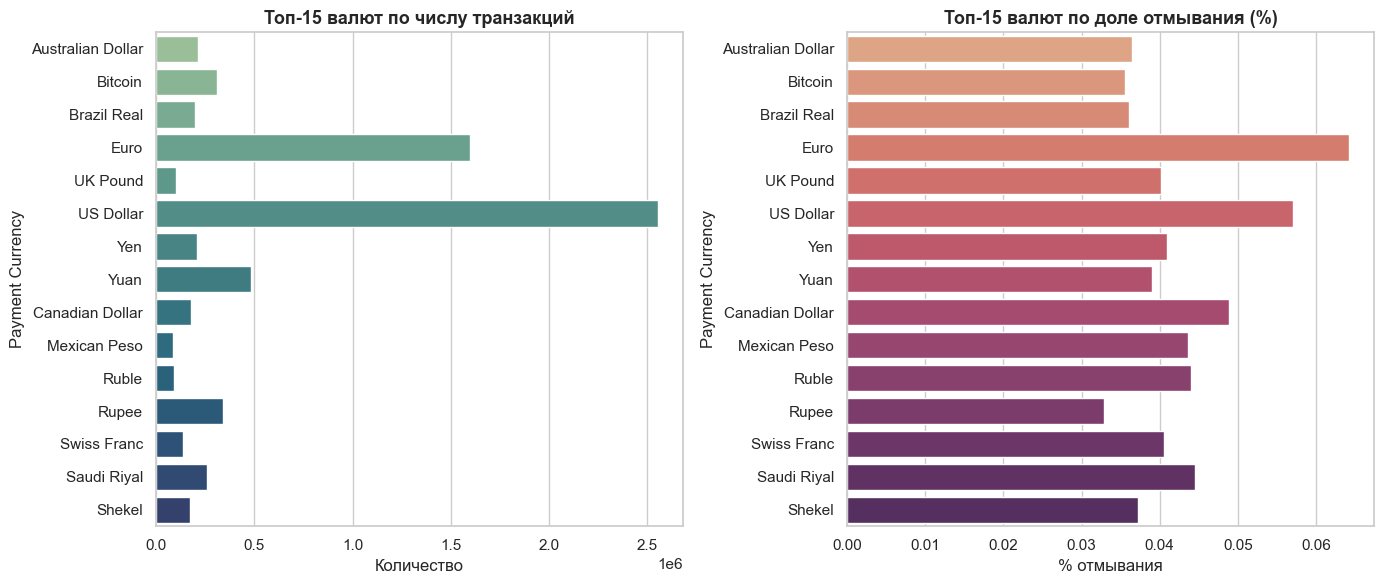

In [47]:
currency_counts = df['Payment Currency'].value_counts()
currency_fraud_rate = df.groupby('Payment Currency')['Is Laundering'].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(y=currency_counts.index[:15], x=currency_counts.values[:15], ax=ax[0], palette="crest")
ax[0].set_title("Топ-15 валют по числу транзакций")
ax[0].set_xlabel("Количество")

sns.barplot(y=currency_fraud_rate.index[:15], x=currency_fraud_rate.values[:15], ax=ax[1], palette="flare")
ax[1].set_title("Топ-15 валют по доле отмывания (%)")
ax[1].set_xlabel("% отмывания")

plt.tight_layout()
plt.show()

### Способы платежа

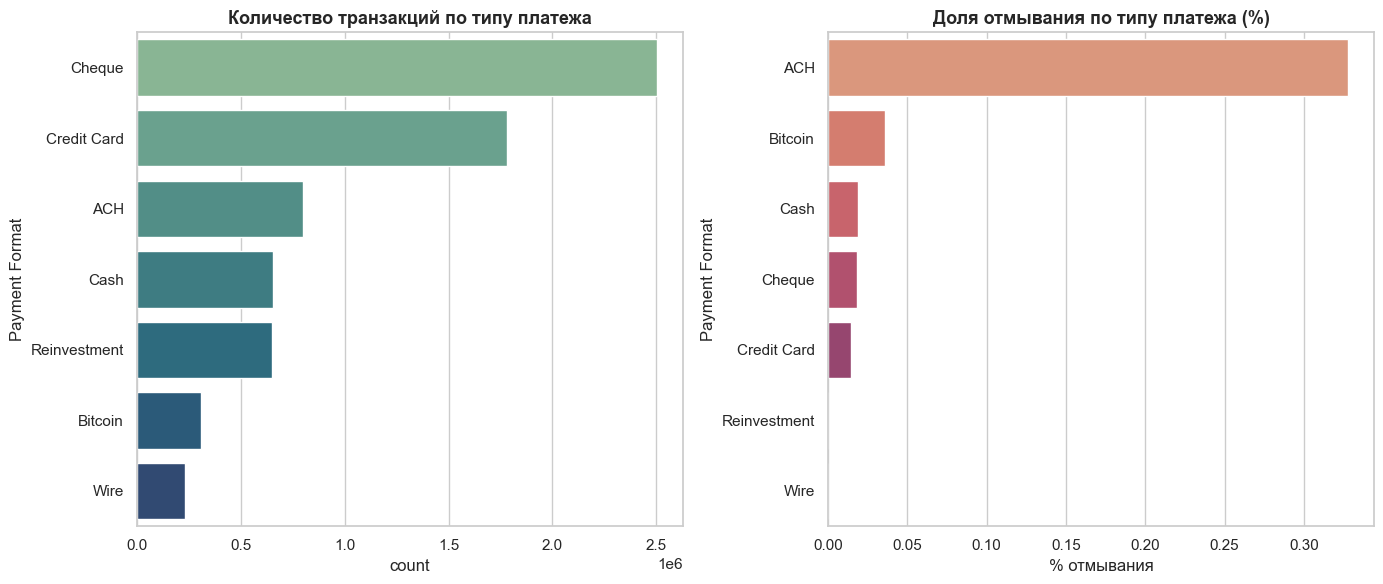

In [48]:
payment_fraud_rate = (df.groupby('Payment Format')['Is Laundering'].mean() * 100).sort_values(ascending=False)
payment_counts = df['Payment Format'].value_counts()

fig, ax = plt.subplots(1, 2, figsize=(14, 6))

sns.countplot(data=df, y='Payment Format', order=payment_counts.index, ax=ax[0], palette="crest")
ax[0].set_title("Количество транзакций по типу платежа")

sns.barplot(x=payment_fraud_rate.values, y=payment_fraud_rate.index, ax=ax[1], palette="flare")
ax[1].set_title("Доля отмывания по типу платежа (%)")
ax[1].set_xlabel("% отмывания")

plt.tight_layout()
plt.show()

### Банки и счета

In [49]:
unique_senders = df['Account'].nunique()
unique_receivers = df['Account.1'].nunique()
unique_banks_from = df['From Bank'].nunique()
unique_banks_to = df['To Bank'].nunique()

print(f"Уникальных счетов-отправителей:  {unique_senders:,}")
print(f"Уникальных счетов-получателей:    {unique_receivers:,}")
print(f"Уникальных банков (отправитель):  {unique_banks_from:,}")
print(f"Уникальных банков (получатель):   {unique_banks_to:,}")

df['is_interbank'] = df['From Bank'].astype('string') != df['To Bank'].astype('string')
interbank_fraud = pd.crosstab(df['is_interbank'], df['Is Laundering'], normalize='index') * 100
print("\nДоля отмывания: внутри банка vs межбанковские транзакции (%):")
interbank_fraud

Уникальных счетов-отправителей:  681,281
Уникальных счетов-получателей:    576,176
Уникальных банков (отправитель):  41,866
Уникальных банков (получатель):   21,620

Доля отмывания: внутри банка vs межбанковские транзакции (%):


Is Laundering,False,True
is_interbank,,
False,99.991996,0.008004
True,99.941917,0.058083


count    705903.000000
mean         19.617565
std         328.239062
min           1.000000
25%           2.000000
50%           6.000000
75%          27.000000
max      223590.000000
Name: total_degree, dtype: float64


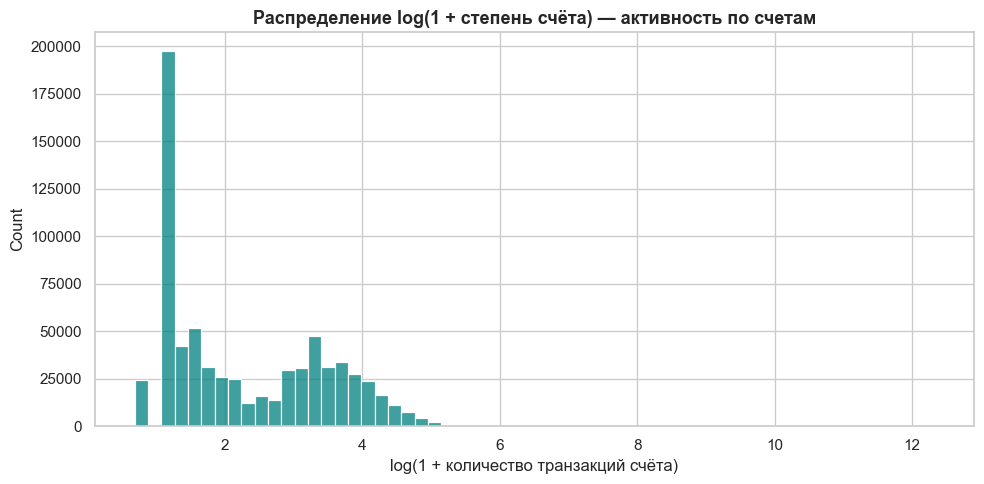

In [50]:
out_degree = df.groupby('Account').size().rename('out_degree')
in_degree = df.groupby('Account.1').size().rename('in_degree')

degree_df = pd.concat([out_degree, in_degree], axis=1).fillna(0)
degree_df['total_degree'] = degree_df['out_degree'] + degree_df['in_degree']

print(degree_df['total_degree'].describe())

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(np.log1p(degree_df['total_degree']), bins=60, ax=ax, color='teal')
ax.set_title("Распределение log(1 + степень счёта) — активность по счетам")
ax.set_xlabel("log(1 + количество транзакций счёта)")
plt.tight_layout()
plt.show()

In [51]:
# Связь степени счёта-отправителя с отмыванием
sender_degree_map = out_degree.to_dict()
df['sender_out_degree'] = df['Account'].map(sender_degree_map)

degree_vs_fraud = df.groupby('Is Laundering')['sender_out_degree'].describe()
degree_vs_fraud

,count,mean,std,min,25%,50%,75%,max
Is Laundering,,,,,,,,
False,6920484.0,10802.528117,43283.133409,1.0,20.0,41.0,80.0,222037.0
True,3565.0,29343.233941,67821.335816,1.0,3.0,18.0,156.0,222037.0


### Корреляционный анализ

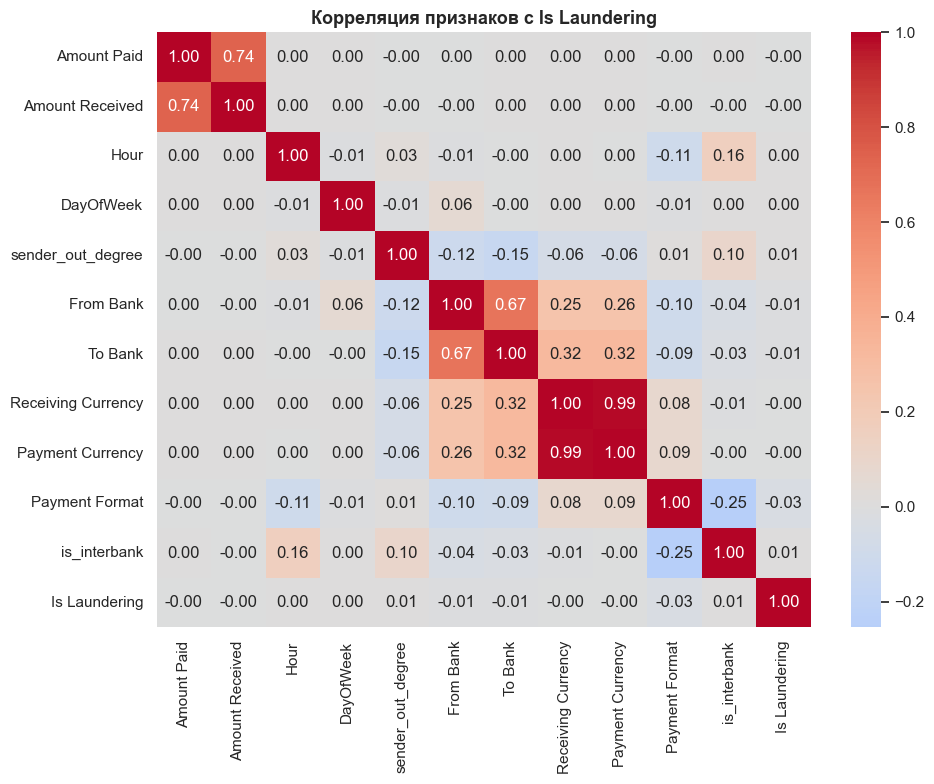

In [52]:
corr_df = df.copy()
for col in ['From Bank', 'To Bank', 'Receiving Currency', 'Payment Currency', 'Payment Format']:
    corr_df[col] = corr_df[col].astype('category').cat.codes

corr_cols = ['Amount Paid', 'Amount Received', 'Hour', 'DayOfWeek', 'sender_out_degree',
             'From Bank', 'To Bank', 'Receiving Currency', 'Payment Currency', 'Payment Format',
             'is_interbank', 'is_currency_exchange', 'Is Laundering']
corr_cols = [c for c in corr_cols if c in corr_df.columns]

corr_matrix = corr_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Корреляция признаков с Is Laundering")
plt.tight_layout()
plt.show()